In [4]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix, accuracy_score
from ssca.ssca import ssca, sample_links, load_moons, load_circles
from sklearn.datasets import load_wine, load_breast_cancer, load_digits, load_iris
load_funcs = (load_wine, load_iris, load_breast_cancer, load_moons, load_circles, load_digits,)

In [5]:
results = {}
for func in load_funcs:
    data_name = func.__name__.replace('load_','')
    results[data_name] = {}
    print(f"Running test for {data_name}")
    X, y = func(return_X_y=True)
    accuracy = []
    calculate_next_best = True
    for i in range(0,200,10):
        must_link, cannot_link = sample_links(i, y)
        y_hat = ssca(X, y, must_link, cannot_link)

        # true and pred are length-n arrays of ints in 0..k-1
        C = confusion_matrix(y, y_hat)          # shape (k,k)

        # we want to maximize trace(C[:, perm]), so minimize -C
        row_ind, col_ind = linear_sum_assignment(-C)

        # row_ind[i] is the true class, col_ind[i] is the matched cluster
        mapping = {cluster: true_cls for true_cls, cluster in zip(row_ind, col_ind)}

        # remap pred→ best true labels
        remapped = np.array([mapping[c] for c in y_hat])

        # now compute accuracy or whatever
        acc = accuracy_score(y, remapped)
        print(f"Best‐case clustering accuracy {i} =", acc)
        accuracy.append((i, acc,))
        results[data_name]['accuracy'] = accuracy


Running test for wine
Best‐case clustering accuracy 0 = 0.7078651685393258
Best‐case clustering accuracy 10 = 0.601123595505618
Best‐case clustering accuracy 20 = 0.7640449438202247
Best‐case clustering accuracy 30 = 0.7303370786516854
Best‐case clustering accuracy 40 = 0.848314606741573
Best‐case clustering accuracy 50 = 0.8820224719101124
Best‐case clustering accuracy 60 = 0.8202247191011236
Best‐case clustering accuracy 70 = 0.898876404494382
Best‐case clustering accuracy 80 = 0.9382022471910112
Best‐case clustering accuracy 90 = 0.949438202247191
Best‐case clustering accuracy 100 = 0.9775280898876404
Best‐case clustering accuracy 110 = 0.9550561797752809
Best‐case clustering accuracy 120 = 0.9943820224719101
Best‐case clustering accuracy 130 = 0.9775280898876404
Best‐case clustering accuracy 140 = 0.9943820224719101
Best‐case clustering accuracy 150 = 0.9887640449438202
Best‐case clustering accuracy 160 = 1.0
Best‐case clustering accuracy 170 = 1.0
Best‐case clustering accuracy 180

In [6]:
func = load_digits
data_name = func.__name__.replace('load_','')
results[data_name] = {}
print(f"Running test for {data_name}")
X, y = func(return_X_y=True)
accuracy = []
calculate_next_best = True
for i in range(0,1500,50):
    must_link, cannot_link = sample_links(i, y)
    y_hat = ssca(X, y, must_link, cannot_link)

    # true and pred are length-n arrays of ints in 0..k-1
    C = confusion_matrix(y, y_hat)          # shape (k,k)

    # we want to maximize trace(C[:, perm]), so minimize -C
    row_ind, col_ind = linear_sum_assignment(-C)

    # row_ind[i] is the true class, col_ind[i] is the matched cluster
    mapping = {cluster: true_cls for true_cls, cluster in zip(row_ind, col_ind)}

    # remap pred→ best true labels
    remapped = np.array([mapping[c] for c in y_hat])

    # now compute accuracy or whatever
    acc = accuracy_score(y, remapped)
    print(f"Best‐case clustering accuracy {i} =", acc)
    accuracy.append((i, acc,))
    results[data_name]['accuracy'] = accuracy

Running test for digits
Best‐case clustering accuracy 0 = 0.7050639955481358
Best‐case clustering accuracy 50 = 0.7885364496382861
Best‐case clustering accuracy 100 = 0.7991096271563717
Best‐case clustering accuracy 150 = 0.8096828046744574
Best‐case clustering accuracy 200 = 0.8174735670562048
Best‐case clustering accuracy 250 = 0.7974401780745687
Best‐case clustering accuracy 300 = 0.8091263216471898
Best‐case clustering accuracy 350 = 0.8124652198107958
Best‐case clustering accuracy 400 = 0.8158041179744018
Best‐case clustering accuracy 450 = 0.9437952142459655
Best‐case clustering accuracy 500 = 0.9415692821368948
Best‐case clustering accuracy 550 = 0.9532554257095158
Best‐case clustering accuracy 600 = 0.9565943238731218
Best‐case clustering accuracy 650 = 0.9699499165275459
Best‐case clustering accuracy 700 = 0.9632721202003339
Best‐case clustering accuracy 750 = 0.9744017807456873
Best‐case clustering accuracy 800 = 0.9799666110183639
Best‐case clustering accuracy 850 = 0.981079

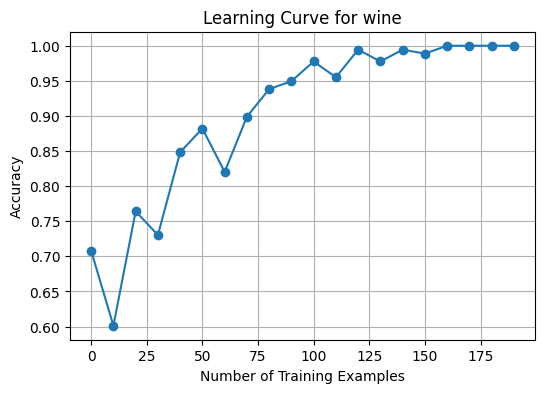

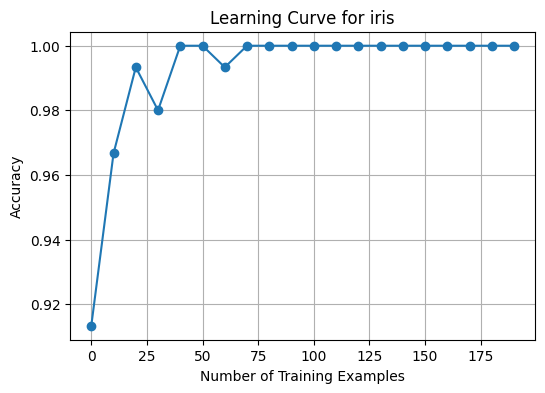

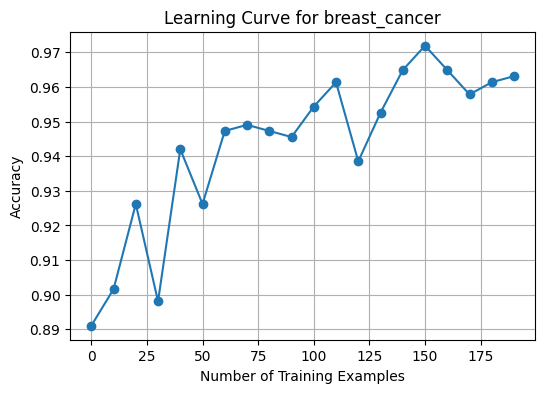

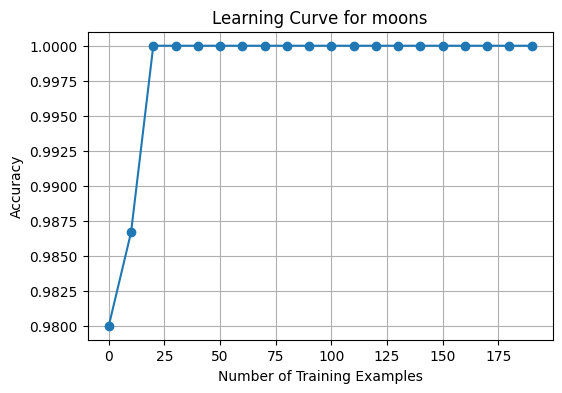

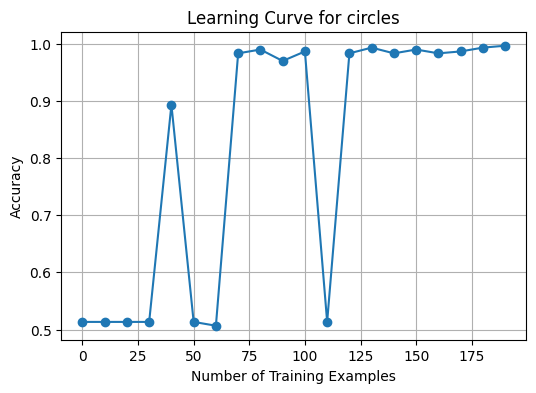

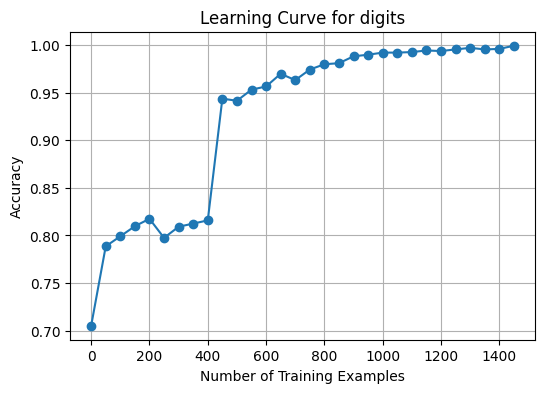

In [7]:

for key, value in results.items():

    # Suppose `data` is your list of (num_examples, accuracy) tuples

    examples, accuracy = zip(*value['accuracy'])

    # Plot
    plt.figure(figsize=(6,4))
    plt.plot(examples, accuracy, marker='o', linestyle='-')
    plt.xlabel('Number of Training Examples')
    plt.ylabel('Accuracy')
    plt.title(f'Learning Curve for {key}')
    plt.grid(True)
    plt.show()

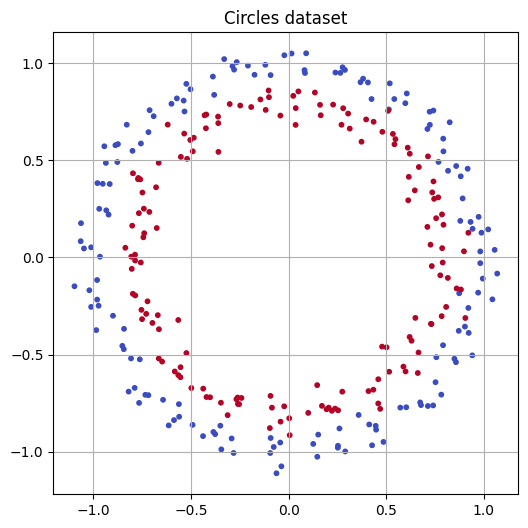

In [8]:
X, y = load_circles()

# Plot the circles
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=10)
plt.title("Circles dataset")
plt.axis('equal')
plt.grid(True)
plt.show()

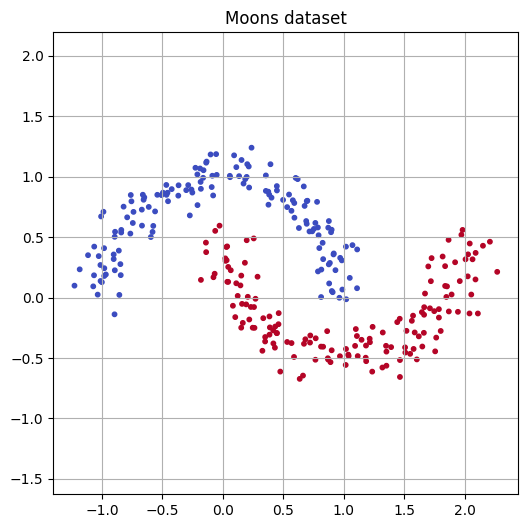

In [9]:
X, y = load_moons()

# Plot the circles
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=10)
plt.title("Moons dataset")
plt.axis('equal')
plt.grid(True)
plt.show()

In [14]:
# time function
sizes = [10, 100, 500, 1000, 2500, 5000, 7500, 10000, 12500]
datasets = []
times = []
for size in sizes:
    n_features = 5
    n_classes = 3
    X = np.random.randn(size, n_features)
    y = np.random.randint(0, n_classes, size)
    datasets.append((X, y,))

for dataset, size  in zip(datasets, sizes):
    X = dataset[0]
    y = dataset[1]
    start = time.time()
    ssca(X, y, [], [])
    times.append(time.time() - start)
    print(size, times)



10 [0.00691986083984375]
100 [0.00691986083984375, 0.025384902954101562]
500 [0.00691986083984375, 0.025384902954101562, 0.39049696922302246]
1000 [0.00691986083984375, 0.025384902954101562, 0.39049696922302246, 1.5210239887237549]
2500 [0.00691986083984375, 0.025384902954101562, 0.39049696922302246, 1.5210239887237549, 10.094325065612793]
5000 [0.00691986083984375, 0.025384902954101562, 0.39049696922302246, 1.5210239887237549, 10.094325065612793, 47.71601390838623]
7500 [0.00691986083984375, 0.025384902954101562, 0.39049696922302246, 1.5210239887237549, 10.094325065612793, 47.71601390838623, 123.48682498931885]
10000 [0.00691986083984375, 0.025384902954101562, 0.39049696922302246, 1.5210239887237549, 10.094325065612793, 47.71601390838623, 123.48682498931885, 243.42495489120483]
12500 [0.00691986083984375, 0.025384902954101562, 0.39049696922302246, 1.5210239887237549, 10.094325065612793, 47.71601390838623, 123.48682498931885, 243.42495489120483, 423.46419191360474]


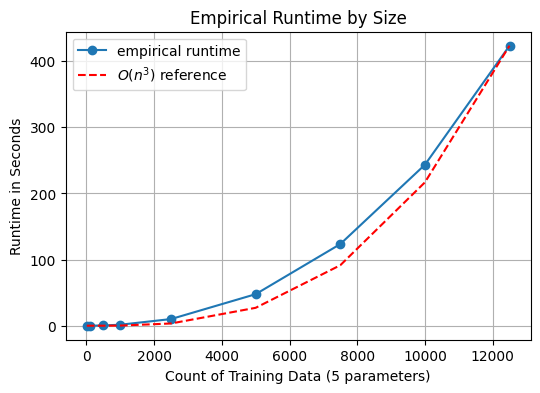

In [18]:
n_cubed = np.array(sizes, dtype=np.float64) ** 3
n_cubed_scaled = n_cubed / n_cubed.max() * max(times)

plt.figure(figsize=(6,4))
plt.plot(sizes, times, marker='o', linestyle='-', label="empirical runtime")
plt.plot(sizes, n_cubed_scaled, linestyle='--', color='red', label=r'$O(n^3)$ reference')
plt.xlabel('Count of Training Data (5 parameters)')
plt.ylabel('Runtime in Seconds')
plt.title(f'Empirical Runtime by Size')
plt.legend(loc='best')
plt.grid(True)
plt.show()